In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras

print("적용된 Keras 백엔드:", keras.config.backend())

적용된 Keras 백엔드: torch


In [2]:
model = keras.models.load_model('best-cnn-model.keras')

In [3]:
model.layers

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

In [5]:
conv = model.layers[0]

In [6]:
print(conv.weights[0].shape, conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [8]:
conv_weights = conv.weights[0].numpy()

In [9]:
print(conv_weights.mean(), conv_weights.std())

-0.020700602 0.2333198


In [10]:
import matplotlib.pyplot as plt

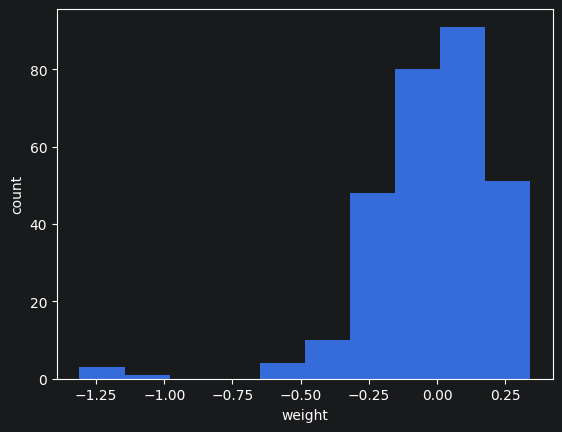

In [11]:
plt.hist(conv_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

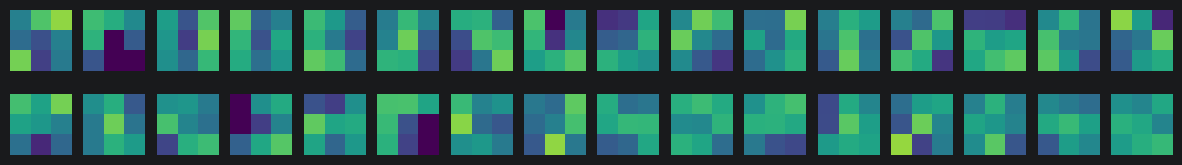

In [13]:
fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[:,:,0,i*16+j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

In [14]:
no_training_model = keras.Sequential()
no_training_model.add(keras.layers.Input(shape=(28,28,1)))
no_training_model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))

In [15]:
no_training_conv = no_training_model.layers[0]
print(no_training_conv.weights[0].shape)

(3, 3, 1, 32)


In [16]:
no_training_weights = no_training_conv.weights[0].numpy()

In [17]:
print(no_training_weights.mean(), no_training_weights.std())

0.0031621528 0.0841106


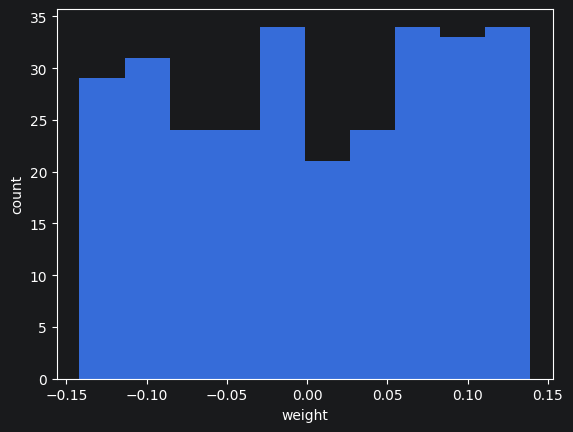

In [18]:
plt.hist(no_training_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

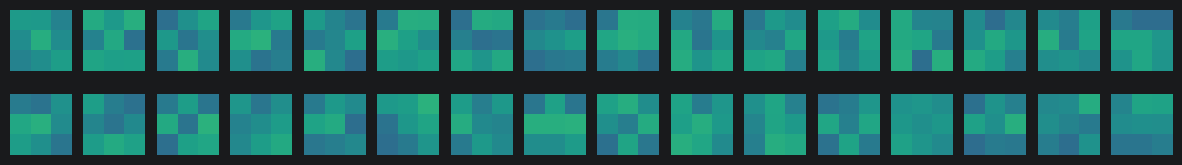

In [19]:
fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(no_training_weights[:,:,0,i*16+j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

In [20]:
inputs = keras.Input(shape=(784, ))
dense1 = keras.layers.Dense(100, activation='relu')
dense2 = keras.layers.Dense(10, activation='softmax')

In [21]:
hidden = dense1(inputs)

In [22]:
outputs = dense2(hidden)

In [23]:
func_model = keras.Model(inputs, outputs)

In [24]:
model.inputs

[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=input_layer>]

In [25]:
conv_acti = keras.Model(model.inputs[0], model.layers[0].output)

In [26]:
(train_input, train_target),  (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

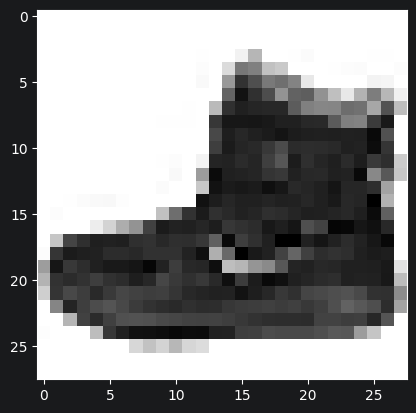

In [28]:
plt.imshow(train_input[0], cmap='gray_r')
plt.show()

In [29]:
ankle_boot = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0

In [30]:
feature_maps = conv_acti.predict(ankle_boot)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


In [31]:
print(feature_maps.shape)

(1, 28, 28, 32)


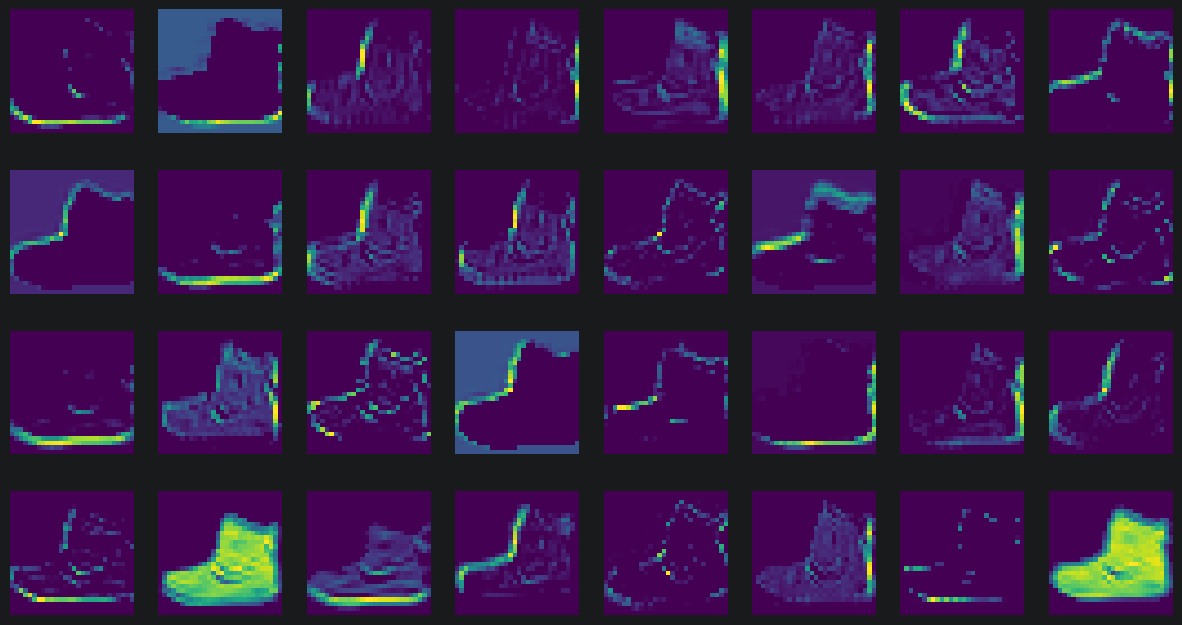

In [33]:
fig, axs = plt.subplots(4, 8, figsize=(15, 8))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8+j])
        axs[i, j].axis('off')
plt.show()

In [34]:
conv2_acti = keras.Model(model.inputs[0], model.layers[2].output)

In [35]:
feature_maps = conv2_acti.predict(ankle_boot)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


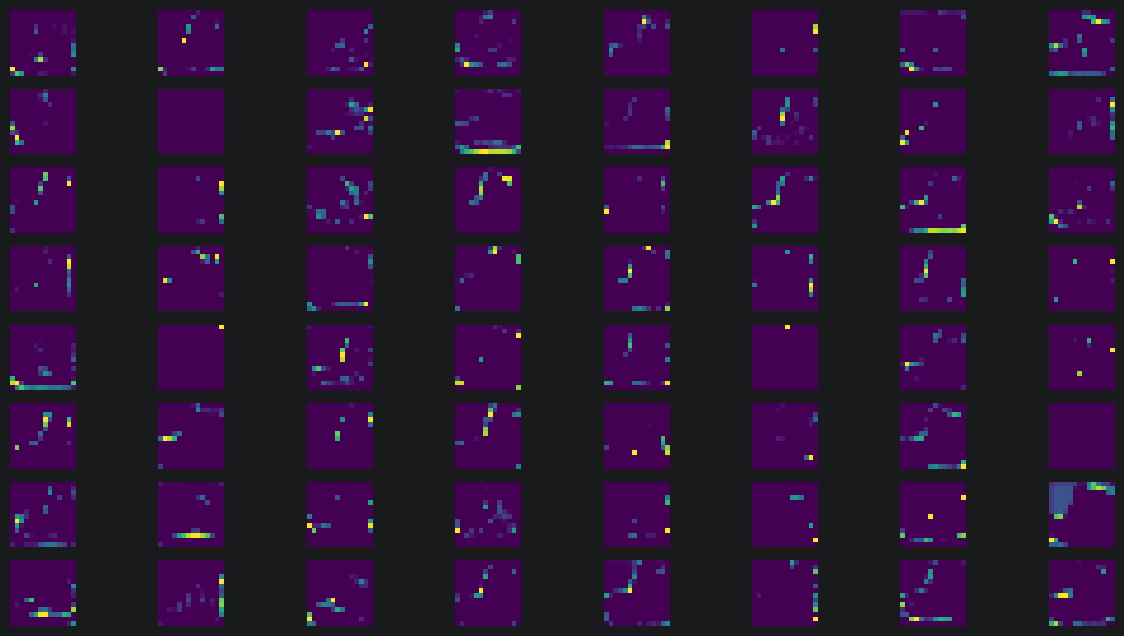

In [36]:
fig, axs = plt.subplots(8, 8, figsize=(15, 8))
for i in range(8):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8+j])
        axs[i, j].axis('off')
plt.show()